# 05 — Seasonal ARIMA (SARIMA) with `pmdarima.auto_arima`

**Data:** hourly `load_mw` from `data/raw/de_lu_load_hourly.parquet`.

1. **Daily totals (`resample("1D").sum()`):** `auto_arima` with `seasonal=True`, **`m = 7`**. Inspect `(p,d,q)×(P,D,Q)`.  
2. **Hourly (last 90 days only):** full-series seasonal ARIMA is heavy — fit on **`m = 24`** over ~**90 × 24** hours (**runs after** the daily forecast block so this notebook finishes the daily story first).  
3. **Residual diagnostics (daily fit):** Ljung–Box on residuals, residual ACF, Gaussianity via Jarque–Bera and **D’Agostino–Pearson** (`scipy.stats.normaltest`).  
4. **Forecast 14 days:** daily point forecast + **95% intervals** vs a **14-day holdout**, plot, and metrics **appended / upserted** in **`results/forecast_metrics.csv`**.

In [2]:
import sys
!{sys.executable} -m pip install pmdarima

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pmdarima as pm
from IPython.display import display
from pmdarima.arima import ndiffs, nsdiffs # Used to estimate the number of differencing operations (d) needed to make a time series stationary. This helps in determining the d parameter for ARIMA models. # pmdarima.arima.nsdiffs: Similar to ndiffs, but specifically for seasonal differencing. It estimates the number of seasonal differencing operations (D) needed to make a time series seasonally stationary, relevant for SARIMA models.
from scipy.stats import normaltest # performs the D'Agostino-Pearson's test, which is a statistical test for assessing whether a sample comes from a normal distribution. It's often used for checking the normality of model residuals.
from statsmodels.graphics.tsaplots import plot_acf # to plot the Autocorrelation Function (ACF) of a time series. The ACF plot helps in identifying the order of the Moving Average (MA) part (q) and seasonal Moving Average (Q) of an ARIMA or SARIMA model, and also in checking for remaining autocorrelation in residuals.
from statsmodels.stats.diagnostic import acorr_ljungbox # Implements the Ljung-Box test for autocorrelation. This test checks whether a series of observations is independently distributed. In time series modeling, it's commonly used to check if the residuals of a fitted model are white noise (i.e., no remaining autocorrelation).
from statsmodels.stats.stattools import jarque_bera # performs the Jarque-Bera test, another statistical test for assessing the normality of a dataset. It's also frequently used for residual diagnostics in time series analysis to check for normality.

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

DATA_PATH = Path("/content/de_lu_load_hourly.parquet")
if not DATA_PATH.is_file():
    DATA_PATH = Path(
        r"C:\Users\mhmta\Cursor_Study\energy-ts-fundamentals\data\raw\de_lu_load_hourly.parquet"
    )

TZ = "Europe/Berlin"
RESULTS_PATH = Path("results/forecast_metrics.csv")
HOLDOUT_DAYS = 14

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.1 MB/s eta 0:00:00


In [3]:
load_hourly = pd.read_parquet(DATA_PATH)
idx = load_hourly.index
if not isinstance(idx, pd.DatetimeIndex):
    load_hourly.index = pd.to_datetime(idx, utc=True)
if load_hourly.index.tz is None:
    load_hourly.index = load_hourly.index.tz_localize(
        TZ, ambiguous="infer", nonexistent="shift_forward"
    )
else:
    load_hourly.index = load_hourly.index.tz_convert(TZ)

y_hourly_full = (
    load_hourly["load_mw"]
    .sort_index()
    .asfreq("1h")
    .interpolate(limit_direction="both")
    .astype(float)
)

y_daily = y_hourly_full.resample("1D").sum().dropna()

min_daily = 2 * 7 + HOLDOUT_DAYS + 5
if len(y_daily) < min_daily:
    raise ValueError(f"Need at least ~{min_daily} daily points for seasonality + holdout.")

print("Hourly rows (full):", len(y_hourly_full))
print("Daily rows:", len(y_daily), "|", y_daily.index.min(), "->", y_daily.index.max())

Hourly rows (full): 26304
Daily rows: 1096 | 2023-01-01 00:00:00+01:00 -> 2025-12-31 00:00:00+01:00


## Daily SARIMA: `seasonal=True`, `m = 7`

In [11]:
train_daily = y_daily.iloc[:-HOLDOUT_DAYS]
test_daily = y_daily.iloc[-HOLDOUT_DAYS:]

daily_diff_hint = ndiffs(train_daily, max_d=3) # Stationary series are easier to model with ARIMA. The max_d=3 argument tells the function to test for at most 3 differencing steps.
daily_sdiff_hint = nsdiffs(train_daily, m=7, max_D=2) # m=7: This specifies the seasonal period. Since your train_daily data is daily, and you're looking for a weekly seasonality, m=7 is used (7 days in a week). # max_D=2: This sets the maximum number of seasonal differences that the function will test for (at most 2 seasonal differencing steps).
print(
    f"pmdarima unit-root helpers: ndiffs≈{daily_diff_hint}, "
    f"nsdiffs (m=7)≈{daily_sdiff_hint} (used only as internal guidance for search)"
)

fit_daily = pm.auto_arima( #  to automatically select the best Seasonal ARIMA (SARIMA) model for your train_daily time series.
    train_daily,
    seasonal=True,
    m=7,
    suppress_warnings=False, # Temporarily set to False to observe warnings directly
    stepwise=True, # This enables a faster, stepwise algorithm for model selection. Instead of checking every possible combination of (p,d,q)(P,D,Q) orders, it intelligently navigates the search space, which is much quicker for complex models.
    error_action="trace", # Changed to 'trace' to get more detailed errors during fitting
    trace=True, # Changed to True to get verbose output of the search progress
    # Added maxiter and n_fits to provide more fitting attempts and control convergence
    maxiter=50,
    n_fits=100,
    method='nm' # Changed optimization method to 'nm' (Nelder-Mead) for potentially better numerical stability
)

print("Selected order (p,d,q):", fit_daily.order)
print("Selected seasonal_order (P,D,Q,m):", fit_daily.seasonal_order)
display(fit_daily.summary())

'''
Non-Seasonal Components (p, d, q):
These describe the non-seasonal part of the ARIMA model:
For example, p=1 means the current value is predicted based on the previous value.
For example, d=1 means the difference between consecutive observations is used.
For example, q=1 means the current value is predicted based on the previous forecast error.
Seasonal Components (P, D, Q)m:
These describe the seasonal part of the ARIMA model, applied at the seasonal period m:
For example, if m=7 (weekly seasonality) and P=1, it would use the value from 7 days ago.
For example, with m=7 and D=1, it would difference the current observation with the observation from 7 days ago.
For example, if you have weekly seasonality (m=7) and Q=1, the model would use the forecast error from exactly one season ago
m (Seasonal period): This specifies the number of observations per season. For daily data with weekly seasonality, m=7. For hourly data with daily seasonality, m=24.
'''

pmdarima unit-root helpers: ndiffs≈0, nsdiffs (m=7)≈0 (used only as internal guidance for search)
Performing stepwise search to minimize aic


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=29042.483, Time=1.98 sec


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=28904.357, Time=0.34 sec


...

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,0,1)(1,0,0)[7] intercept   : AIC=28376.028, Time=1.98 sec
 ARIMA(1,0,0)(1,0,0)[7]             : AIC=27246.933, Time=1.11 sec

Best model:  ARIMA(1,0,0)(1,0,0)[7] intercept
Total fit time: 16.089 seconds
Selected order (p,d,q): (1, 0, 0)
Selected seasonal_order (P,D,Q,m): (1, 0, 0, 7)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                 1082
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 7)   Log Likelihood              -13593.516
Date:                           Sun, 10 May 2026   AIC                          27195.033
Time:                                   14:34:46   BIC                          27214.979
Sample:                               01-01-2023   HQIC                         27202.585
                                    - 12-17-2025                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   1.064e+04   2626.663      4.051      0.000    5491.376    1.58e+04
ar.L1          0.8886      0.012     75.369      0.000       0.865       0.912
ar.S.L7        0.9298      0.012     78.448      0.000       0.907       0.953
sigma2      4.046e+09      0.040   1.02e+11      0.000    4.05e+09    4.05e+09
===================================================================================
Ljung-Box (L1) (Q):                  30.09   Jarque-Bera (JB):              2246.68
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.12   Skew:                            -0.32
Prob(H) (two-sided):                  0.29   Kurtosis:                        10.03
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.18e+25. Standard errors may be unstable.
"""

'\nNon-Seasonal Components (p, d, q):\nThese describe the non-seasonal part of the ARIMA model:\nFor example, p=1 means the current value is predicted based on the previous value.\nFor example, d=1 means the difference between consecutive observations is used.\nFor example, q=1 means the current value is predicted based on the previous forecast error.\nSeasonal Components (P, D, Q)m:\nThese describe the seasonal part of the ARIMA model, applied at the seasonal period m:\nFor example, if m=7 (weekly seasonality) and P=1, it would use the value from 7 days ago.\nFor example, with m=7 and D=1, it would difference the current observation with the observation from 7 days ago.\nFor example, if you have weekly seasonality (m=7) and Q=1, the model would use the forecast error from exactly one season ago\nm (Seasonal period): This specifies the number of observations per season. For daily data with weekly seasonality, m=7. For hourly data with daily seasonality, m=24.\n'

AIC, BIC, and HQIC are all information criteria used in statistical modeling, especially for time series models like ARIMA, to help select the best model among a set of candidates. They provide a way to balance the goodness of fit of a model with its complexity (number of parameters). Generally, a lower value for any of these criteria indicates a better model.

Here's a breakdown of each:

- AIC (Akaike Information Criterion)

  - Formula (general form): AIC = 2k - 2ln(L)
    - k is the number of parameters in the model.
    - L is the maximum likelihood estimate for the model.
  - Purpose: AIC estimates the relative amount of information lost by a given model. The idea is to find a model that explains the data well without overfitting. When comparing models, the one with the lowest AIC is generally preferred. It penalizes complexity less heavily than BIC.
- BIC (Bayesian Information Criterion)

    - Formula (general form): BIC = kln(n) - 2ln(L)
      - k is the number of parameters in the model.
      - n is the number of observations (data points).
      - L is the maximum likelihood estimate for the model.
  - Purpose: Like AIC, BIC is used for model selection, with a lower BIC indicating a better model. However, BIC introduces a stronger penalty for the number of parameters (k) as it also considers the number of observations (n). This means BIC tends to prefer simpler models (fewer parameters) than AIC, especially with larger datasets.
- HQIC (Hannan-Quinn Information Criterion)

  - Formula (general form): HQIC = 2kln(ln(n)) - 2ln(L)
      - k is the number of parameters in the model.
      - n is the number of observations (data points).
      - L is the maximum likelihood estimate for the model.
    - Purpose: HQIC is another criterion for model selection, aiming to find a balance between model fit and complexity. Its penalty for the number of parameters (k) is between that of AIC and BIC. Specifically, for large sample sizes, HQIC's penalty is stronger than AIC but weaker than BIC. While less commonly used than AIC and BIC, it's particularly useful in certain contexts and has some theoretical advantages in terms of consistency.
In summary:

- AIC: Good for prediction, tends to select more complex models.
- BIC: Good for identifying the true underlying model, tends to select simpler models.
- HQIC: A compromise between AIC and BIC, with a penalty that grows slightly faster than AIC but slower than BIC as n increases.

1.Model Parameters and Coefficients

Covariance Type: opg: This indicates the method used to estimate the covariance matrix of the parameters. 'opg' stands for 'Outer Product of Gradients', which is a common method for robust standard error estimation.

intercept: This is the estimated constant term of the model. A p-value of 0.000 (which is less than typical significance levels like 0.05) indicates that the intercept is statistically significant and likely contributes to the model's predictions.

ma.L1: This is the coefficient for the non-seasonal Moving Average (MA) term at lag 1 (q=1). It suggests that the current value is strongly influenced by the forecast error from the previous period. The 0.000 p-value indicates it's highly significant.

ar.S.L7:This is the coefficient for the seasonal Autoregressive (SAR) term at seasonal lag 7 (P=2, but only one term shown here at lag 7). The negative coefficient suggests a strong inverse relationship with the value from 7 periods ago (one season ago). The high significance (0.000 p-value) indicates a clear weekly seasonal pattern.

sigma2: This is the estimated variance of the error term (residuals) in the model. A lower sigma2 generally indicates a better fit. Its statistical significance implies that it's a non-zero value.

2.Diagnostic Tests (Residual Analysis)

These tests evaluate the properties of the model's residuals, which are the differences between the actual and predicted values. Ideally, residuals should be white noise (no autocorrelation, normally distributed, and homoscedastic).

Ljung-Box (L1) (Q): This tests for the presence of autocorrelation in the residuals. The null hypothesis is that there is no autocorrelation up to a specified lag.

Jarque-Bera (JB): This is a test for normality of the residuals. The null hypothesis is that the residuals are normally distributed. A small p-value would indicate that the residuals are not normally distributed.

Heteroskedasticity (H): This tests for heteroscedasticity, which means the variance of the residuals is not constant across all levels of the independent variables. The null hypothesis is that the residuals are homoscedastic (constant variance). A small p-value suggests heteroscedasticity.

Skew: Skewness measures the asymmetry of the residuals' distribution. For a perfectly normal distribution, skewness is 0.

Kurtosis: Kurtosis measures the 'tailedness' of the residuals' distribution. For a normal distribution, excess kurtosis is 0. High kurtosis indicates more extreme outliers (fat tails).

## Residual diagnostics (daily model, training window)

In [12]:
resid_daily = ( # to extract the residuals (the differences between the actual values and the model's predictions) from the fit_daily ARIMA model and prepare them for analysis.
    pd.Series(fit_daily.arima_res_.resid, index=train_daily.index) # After pm.auto_arima fits a model, the actual statsmodels ARIMA results object is stored in fit_daily.arima_res_. This object has a .resid attribute, which contains the residuals (forecast errors) of the model for the training data.
    .replace([np.inf, -np.inf], np.nan) # Sometimes, during model fitting, residuals can become infinite due to numerical issues (e.g., division by zero, or very small denominators leading to extremely large numbers). This step replaces any positive (np.inf) or negative (-np.inf) infinite values with np.nan (Not a Number).
    .dropna()
)
if len(resid_daily) < 20:
    raise ValueError("Not enough residuals for diagnostics.")

_p, _d, _q = fit_daily.order
_P, _D, _Q, _m = fit_daily.seasonal_order
lb_model_df = int(_p + _q + _P + _Q) # calculates a value used as the model_df (degrees of freedom) parameter in the acorr_ljungbox function, which performs the Ljung-Box test.
# You provide the number of parameters (k) that were estimated in your ARIMA model. The Ljung-Box test then adjusts its degrees of freedom by subtracting k from the standard degrees of freedom. This adjustment ensures that the test provides a more accurate p-value

max_lb_lag = min(14, max(5, len(resid_daily) // 10)) #  calculates the maximum number of lags to consider when performing the Ljung-Box test (acorr_ljungbox). This is important because the Ljung-Box test checks for autocorrelation at different lags, and you don't want to test too many or too few.
lb = acorr_ljungbox( # This line of code is performing the Ljung-Box test on the residuals of your daily SARIMA model. The Ljung-Box test is a statistical test that checks for the presence of autocorrelation in a time series.
    resid_daily,
    lags=[max_lb_lag],
    return_df=True,
    model_df=lb_model_df,
)
print(
    "Ljung–Box (small p suggests remaining autocorrelation); model_df ≈ p+q+P+Q =",
    lb_model_df,
)
display(lb)

jb_stat, jb_p, skew_, kurt_ = jarque_bera(resid_daily.values) # This line is performing the Jarque-Bera test on your model's residuals to assess their normality. The Jarque-Bera test is a statistical test that determines whether sample data has the skewness and kurtosis matching a normal distribution.
print(
    "Jarque–Bera (normality): "
    f"JB={jb_stat:,.4f}, p-value={jb_p:.4g}, skew={skew_:,.4f}, kurtosis={kurt_:,.4f}"
)

dp_stat, dp_p = normaltest(resid_daily.values) # This line performs the D’Agostino-Pearson’s test for normality on your model's residuals. This is another statistical test (similar in purpose to Jarque-Bera) used to determine if a sample of data comes from a normal distribution. It's often more robust for smaller sample sizes compared to Jarque-Bera.
print(f"D’Agostino–Pearson normaltest: statistic={dp_stat:,.4f}, p-value={dp_p:.4g}")

Ljung–Box (small p suggests remaining autocorrelation); model_df ≈ p+q+P+Q = 2


,lb_stat,lb_pvalue
14,356.3178,0.0000


Jarque–Bera (normality): JB=2,280.4262, p-value=0, skew=-0.3805, kurtosis=10.0713
D’Agostino–Pearson normaltest: statistic=186.8658, p-value=2.646e-41


Ideal Residuals: In time series modeling (like ARIMA), the ideal scenario is that the model's residuals are Gaussian White Noise. This means the residuals are:

- White Noise: There's no remaining autocorrelation, indicating the model has captured all the predictable patterns.
- Normally Distributed: This allows for more accurate statistical inference, such as constructing confidence intervals for forecasts, as many statistical tests and properties rely on the assumption of normality.

So, while a good model strives for residuals that are both white noise and normally distributed, these are two distinct properties. The Ljung-Box test checks for the 'white noise' property (no autocorrelation), while tests like Jarque-Bera and D'Agostino-Pearson check for the 'normal distribution' property.

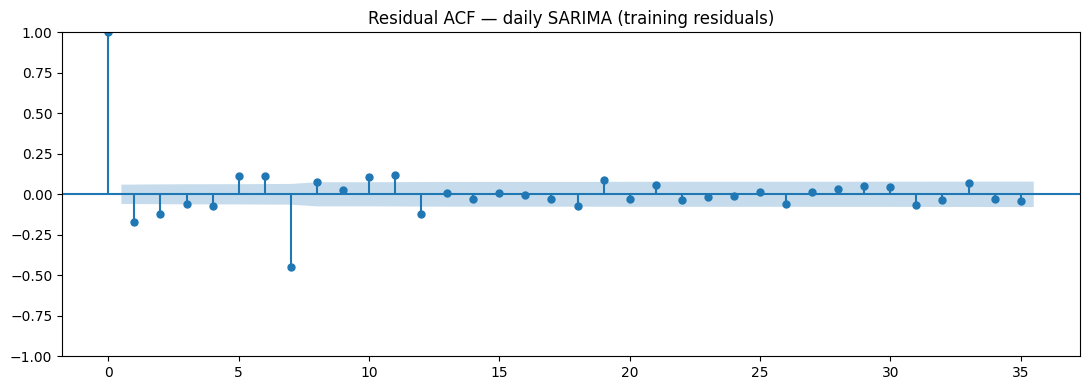

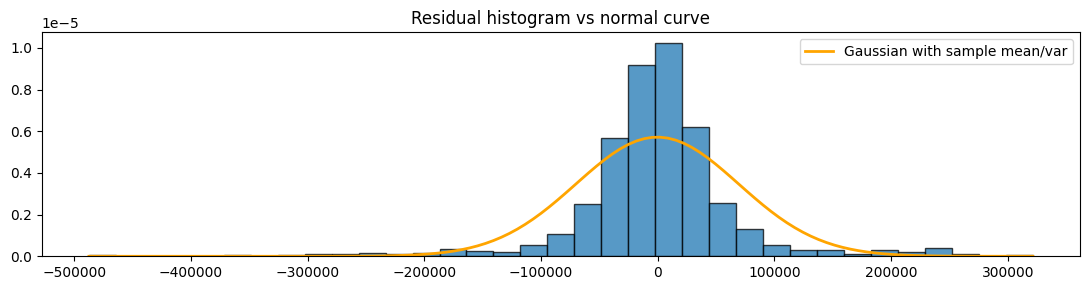

In [13]:
acf_lags = min(35, len(resid_daily) // 2 - 1)
fig = plt.figure(figsize=(11, 4))
ax = fig.subplots()
plot_acf(resid_daily, ax=ax, lags=acf_lags, title="Residual ACF — daily SARIMA (training residuals)")
# plot_acf(...): This function from statsmodels.graphics.tsaplots is specifically designed to create an ACF plot. It visualizes these correlations for various lags.
fig.tight_layout()

fig2, ax2 = plt.subplots(figsize=(11, 3))
ax2.hist(resid_daily, bins=min(35, len(resid_daily) // 4), density=True, # When density=True, the histogram displays the probability density rather than the raw counts. This means the area under the histogram bars will sum to 1, making it easier to compare the shape of the residual distribution to a theoretical probability distribution
         alpha=0.75, # A value of 0.75 means the bars are 75% opaque, allowing any underlying grid or other plots to be partially visible.
         edgecolor="k")
mu, sig = resid_daily.mean(), resid_daily.std(ddof=1) # These mu and sig values are then used in the subsequent lines to generate a theoretical normal probability density function (PDF) that has the same mean and standard deviation as your observed residuals.
xs = np.linspace(resid_daily.min(), resid_daily.max(), 120) # he resulting xs array will contain 120 values spanning the range of your residuals. These xs values will then be used as input to the probability density function (PDF) of a normal distribution
pdf = (
    np.exp(-0.5 * ((xs - mu) / sig) ** 2) / (sig * np.sqrt(2 * np.pi))
    if sig > 0
    else np.zeros_like(xs)
)
ax2.plot(xs, pdf, color="orange", lw=2, label="Gaussian with sample mean/var")
ax2.set_title("Residual histogram vs normal curve")
ax2.legend()
fig2.tight_layout()

## 14-day-ahead forecast (daily) with 95% intervals

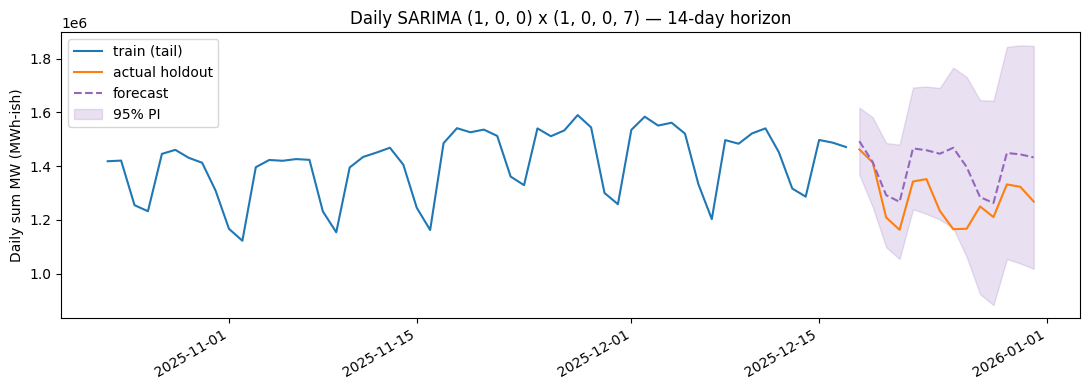

In [14]:
fc, conf_int = fit_daily.predict( #  This is the method of the pmdarima ARIMA model object (fit_daily) used to generate predictions (forecasts) for future time steps.
    n_periods=HOLDOUT_DAYS, return_conf_int=True, # This argument tells the predict method to not only return the point forecasts (fc) but also to calculate and return the confidence intervals around those forecasts.
                                  alpha=0.05) # The conf_int array will contain intervals such that there's a 95% probability that the true future value lies within the calculated lower and upper bounds.

last_train = train_daily.index.max()
fc_index = pd.date_range( # This is a powerful pandas function used to generate a fixed frequency DatetimeIndex (a sequence of dates). It's perfect for creating the time axis for your forecasts.
    last_train + pd.Timedelta(days=1), # By adding one day to last_train, you get the first date of your forecast horizon. This ensures that the forecast starts immediately after the training data ends.
    periods=HOLDOUT_DAYS,
    freq="D", #  This sets the frequency of the generated dates to 'Daily' (one date per day). This matches the daily frequency of your y_daily data.
    tz=last_train.tz,
)
pred_ser = pd.Series(fc, index=fc_index) # This Series holds the forecasted values (fc) and assigns them a proper time-based index (fc_index).
lo = pd.Series(conf_int[:, 0], index=fc_index)
hi = pd.Series(conf_int[:, 1], index=fc_index)

show_hist = min(56, len(train_daily))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(train_daily.index[-show_hist:], train_daily.iloc[-show_hist:], label="train (tail)")
ax.plot(test_daily.index, test_daily.values, label="actual holdout")
ax.plot(pred_ser.index, pred_ser.values, linestyle="--", color="tab:purple", label="forecast")
ax.fill_between(fc_index, lo.values, hi.values, color="tab:purple", alpha=0.2, label="95% PI")
ax.legend()
ax.set_title(
    f"Daily SARIMA {fit_daily.order} x {fit_daily.seasonal_order} — 14-day horizon"
)
ax.set_ylabel("Daily sum MW (MWh-ish)")
fig.autofmt_xdate()
fig.tight_layout()

### Hourly (last 90 days): `seasonal=True`, `m = 24`

In [15]:
n_hour_90 = 90 * 24
y_hourly = y_hourly_full.iloc[-n_hour_90:]
print("Hourly subset (last 90 d):", len(y_hourly), "rows")

fit_hourly = pm.auto_arima(
    y_hourly,
    seasonal=True,
    m=24,
    suppress_warnings=True,
    stepwise=True,
    error_action="warn",
)

print("Hourly subset — chosen order:", fit_hourly.order)
print("Hourly subset — chosen seasonal_order:", fit_hourly.seasonal_order)
display(fit_hourly.summary())

Hourly subset (last 90 d): 2160 rows
Hourly subset — chosen order: (1, 1, 1)
Hourly subset — chosen seasonal_order: (1, 0, 1, 24)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                 2160
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 24)   Log Likelihood              -17822.672
Date:                            Sun, 10 May 2026   AIC                          35657.344
Time:                                    15:06:30   BIC                          35691.409
Sample:                                10-03-2025   HQIC                         35669.803
                                     - 12-31-2025                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -2.4904      5.643     -0.441      0.659     -13.551       8.570
ar.L1          0.3932      0.009     41.562      0.000       0.375       0.412
ma.L1          0.3470      0.013     26.040      0.000       0.321       0.373
ar.S.L24       0.9336      0.004    228.407      0.000       0.926       0.942
ma.S.L24      -0.6784      0.010    -67.260      0.000      -0.698      -0.659
sigma2      7.898e+05   1.68e+04     46.968      0.000    7.57e+05    8.23e+05
===================================================================================
Ljung-Box (L1) (Q):                  19.20   Jarque-Bera (JB):             41072.11
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.42   Skew:                            -0.87
Prob(H) (two-sided):                  0.00   Kurtosis:                        24.30
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## Results table (`results/forecast_metrics.csv`)

In [16]:
def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    eps = np.finfo(float).eps
    return float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100.0)


def smape(y_true: np.ndarray, y_pred: np.ndarray) -> float: # The smape function calculates the Symmetric Mean Absolute Percentage Error (sMAPE). It's a common metric used to evaluate the accuracy of forecasts, particularly in time series analysis
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom > np.finfo(float).eps # mask = denom > np.finfo(float).eps: This creates a boolean mask to handle cases where the denominator might be zero or extremely close to zero (which would lead to division by zero errors). np.finfo(float).eps represents the smallest positive floating-point number.
    return float(
        np.mean(200.0 * np.abs(y_true[mask] - y_pred[mask]) / denom[mask])
    )


y_hat = pred_ser.reindex(test_daily.index).values.astype(float)
y_act = test_daily.values.astype(float)
if np.any(np.isnan(y_hat)):
    raise ValueError("Forecast index misaligned with holdout.")

_aic_daily = getattr(fit_daily.arima_res_, "aic", np.nan)
_bic_daily = getattr(fit_daily.arima_res_, "bic", np.nan)
_aic_hourly = getattr(fit_hourly.arima_res_, "aic", np.nan)

row = {
    "notebook": "05_sarima",
    "frequency": "D",
    "method": "SARIMA (pmdarima auto_arima, m=7)",
    "order": str(fit_daily.order),
    "seasonal_order": str(fit_daily.seasonal_order),
    "hourly_subset_days": np.nan,
    "holdout_horizon_days": HOLDOUT_DAYS,
    "AIC": _aic_daily,
    "BIC": _bic_daily,
    "ljung_box_lag_used": float(max_lb_lag),
    "ljung_box_pvalue": float(lb["lb_pvalue"].iloc[-1]),
    "jarque_bera_pvalue": jb_p,
    "dagostino_pearson_pvalue": dp_p,
    "MAE": mae(y_act, y_hat),
    "RMSE": rmse(y_act, y_hat),
    "MAPE_pct": mape(y_act, y_hat),
    "sMAPE_pct": smape(y_act, y_hat),
}

row_h = {
    "notebook": "05_sarima",
    "frequency": "h",
    "method": "SARIMA (pmdarima auto_arima, last 90d, m=24)",
    "order": str(fit_hourly.order),
    "seasonal_order": str(fit_hourly.seasonal_order),
    "hourly_subset_days": 90.0,
    "holdout_horizon_days": np.nan,
    "AIC": _aic_hourly,
    "BIC": np.nan,
    "ljung_box_lag_used": np.nan,
    "ljung_box_pvalue": np.nan,
    "jarque_bera_pvalue": np.nan,
    "dagostino_pearson_pvalue": np.nan,
    "MAE": np.nan,
    "RMSE": np.nan,
    "MAPE_pct": np.nan,
    "sMAPE_pct": np.nan,
}

new_rows = pd.DataFrame([row, row_h])
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
if RESULTS_PATH.is_file():
    existing = pd.read_csv(RESULTS_PATH)
    combined = pd.concat([existing, new_rows], ignore_index=True)
    key = [
        "notebook",
        "frequency",
        "method",
        "order",
        "seasonal_order",
        "hourly_subset_days",
        "holdout_horizon_days",
    ]
    combined = combined.drop_duplicates(subset=key, keep="last")
else:
    combined = new_rows
combined.sort_values(by=["frequency", "method"], inplace=True, ignore_index=True)
combined.to_csv(RESULTS_PATH, index=False)
print(f"Appended / updated rows in {RESULTS_PATH.resolve()}")
display(combined)

Appended / updated rows in /content/results/forecast_metrics.csv


,notebook,frequency,method,order,seasonal_order,hourly_subset_days,holdout_horizon_days,AIC,BIC,ljung_box_lag_used,ljung_box_pvalue,jarque_bera_pvalue,dagostino_pearson_pvalue,MAE,RMSE,MAPE_pct,sMAPE_pct
0,05_sarima,D,"SARIMA (pmdarima auto_arima, m=7)","(1, 0, 0)","(1, 0, 0, 7)",NaN,14.0000,"27,195.0326","27,214.9789",14.0000,0.0000,0.0000,0.0000,"120,121.8811","144,841.8907",9.6997,9.0480
1,05_sarima,h,"SARIMA (pmdarima auto_arima, last 90d, m=24)","(1, 1, 1)","(1, 0, 1, 24)",90.0000,NaN,"35,657.3441",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
